In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

BASE_PATH = '/content/drive/MyDrive/RAF-CE'
IMG_PATH = os.path.join(BASE_PATH, 'images', 'aligned')
ANNOT_PATH = os.path.join(BASE_PATH, 'annotations')

print("Nombre d'images dans aligned :", len(os.listdir(IMG_PATH)))
print("Fichiers annotations :", os.listdir(ANNOT_PATH))

Nombre d'images dans aligned : 4908
Fichiers annotations : ['RAFCE_AUlabel.txt', 'RAFCE_emolabel.txt', 'RAFCE_partition.txt']


# Préparation des données (Couche 1)

In [ ]:
emolabel = pd.read_csv(os.path.join(ANNOT_PATH, 'RAFCE_emolabel.txt'),
                       sep=' ', header=None, names=['filename', 'label'])

aulabel = pd.read_csv(os.path.join(ANNOT_PATH, 'RAFCE_AUlabel.txt'),
                      sep=' ', header=None, names=['filename', 'au_string'])

partition = pd.read_csv(os.path.join(ANNOT_PATH, 'RAFCE_partition.txt'),
                        sep=' ', header=None, names=['filename', 'split'])

df = emolabel.merge(partition, on='filename').merge(aulabel, on='filename')

class_names = [
    'Happily surprised', 'Happily disgusted', 'Sadly fearful', 'Sadly angry',
    'Sadly surprised', 'Sadly disgusted', 'Fearfully angry', 'Fearfully surprised',
    'Fearfully disgusted', 'Angrily surprised', 'Angrily disgusted',
    'Disgustedly surprised', 'Happily fearful', 'Happily sad'
]

df['class_name'] = df['label'].map(lambda x: class_names[int(x)])
df['split_name'] = df['split'].map({0: 'train', 1: 'test', 2: 'val'})

print(f"Total images : {len(df)}")
print("\nRépartition des splits :")
print(df['split_name'].value_counts())
print("\nDistribution des classes (du plus rare au plus fréquent) :")
print(df['class_name'].value_counts().sort_values())

Total images : 4549

Répartition des splits :
split_name
train    2709
val       931
test      909
Name: count, dtype: int64

Distribution des classes (du plus rare au plus fréquent) :
class_name
Happily fearful           11
Happily sad               29
Fearfully disgusted       36
Sadly surprised          120
Sadly fearful            171
Disgustedly surprised    177
Fearfully angry          195
Angrily surprised        210
Sadly angry              230
Happily disgusted        279
Fearfully surprised      603
Happily surprised        676
Sadly disgusted          835
Angrily disgusted        977
Name: count, dtype: int64


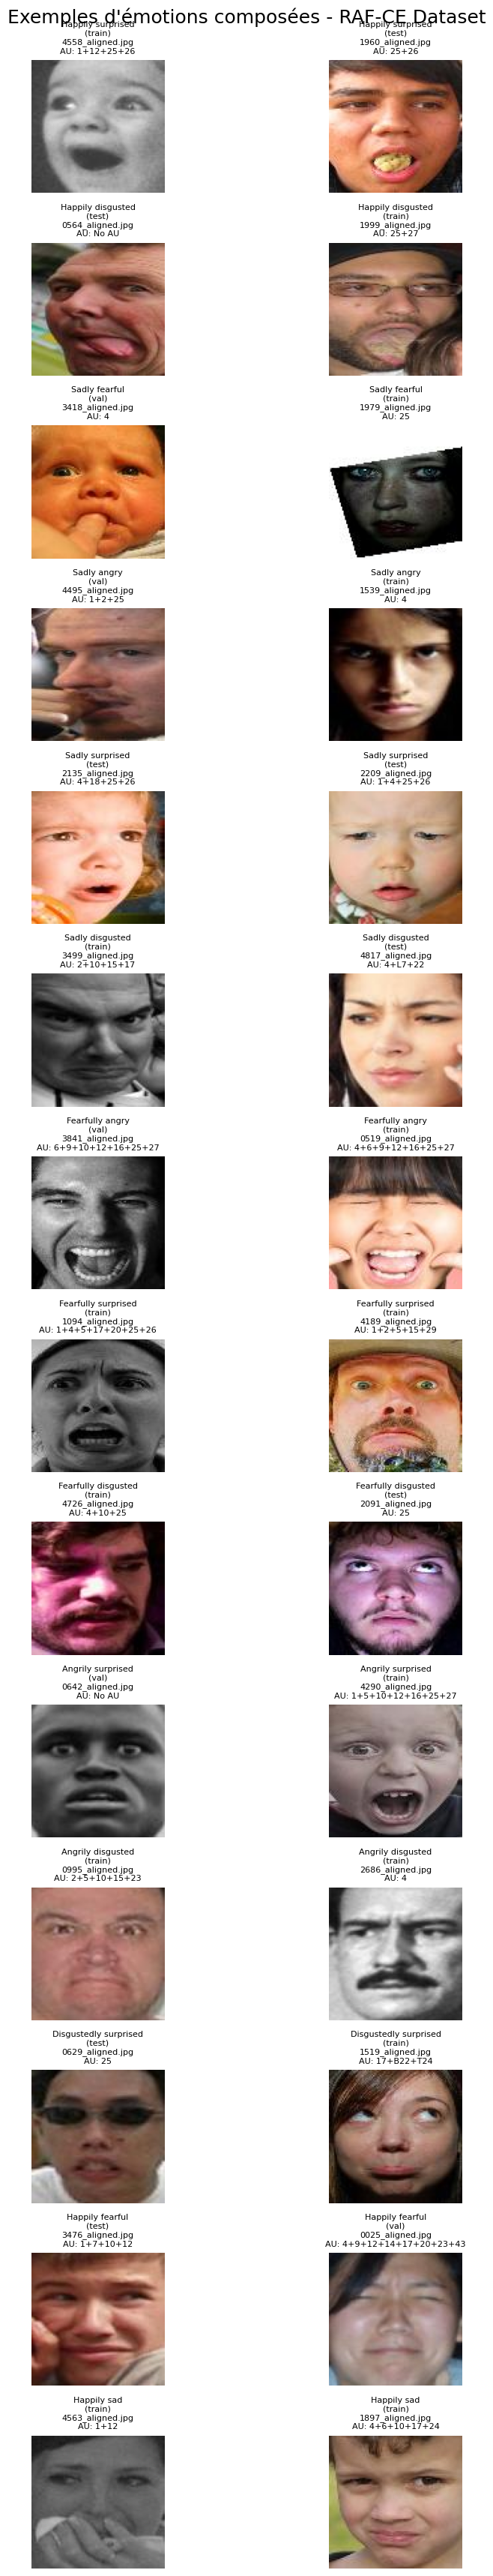

Visualisation terminée.
Images manquantes (fichier) : 0
Annotations AU manquantes ou 'null' : 2


In [ ]:
def show_examples_final(df, num_per_class=2, seed=42):
    np.random.seed(seed)
    fig, axes = plt.subplots(14, num_per_class, figsize=(10, 35))
    fig.suptitle('Exemples d\'émotions composées - RAF-CE Dataset', fontsize=18)

    missing_count = 0
    au_missing_count = 0

    for i, class_name in enumerate(class_names):
        class_df = df[df['class_name'] == class_name]
        samples = class_df.sample(min(num_per_class, len(class_df)), random_state=seed)

        for j in range(num_per_class):
            ax = axes[i, j]
            if j < len(samples):
                row = samples.iloc[j]
                base_name = row['filename']
                aligned_name = base_name.replace('.jpg', '_aligned.jpg')
                img_path = os.path.join(IMG_PATH, aligned_name)

                if os.path.exists(img_path):
                    img = Image.open(img_path)
                    ax.imshow(img)

                    # Gestion sécurisée des AU
                    au_raw = row['au_string']
                    if pd.isna(au_raw) or au_raw == 'null' or au_raw is None:
                        au_short = 'No AU'
                        au_missing_count += 1
                    else:
                        au_str = str(au_raw)
                        au_short = au_str[:30] + ('...' if len(au_str) > 30 else '')

                    ax.set_title(f"{class_name}\n({row['split_name']})\n{aligned_name}\nAU: {au_short}",
                                 fontsize=8)
                else:
                    ax.text(0.5, 0.5, 'Image non trouvée !', ha='center', va='center', color='red', transform=ax.transAxes)
                    missing_count += 1
            else:
                ax.text(0.5, 0.5, 'Pas assez d\'exemples', ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.96)
    plt.show()

    print(f"Visualisation terminée.")
    print(f"Images manquantes (fichier) : {missing_count}")
    print(f"Annotations AU manquantes ou 'null' : {au_missing_count}")


show_examples_final(df)

In [ ]:
!pip install -q datasets transformers accelerate pillow

In [ ]:
from datasets import Dataset, DatasetDict, Features, Value, ClassLabel, Image as HFImage
import os
from PIL import Image as PILImage

# Définition des features
class_names = [
    'Happily surprised', 'Happily disgusted', 'Sadly fearful', 'Sadly angry',
    'Sadly surprised', 'Sadly disgusted', 'Fearfully angry', 'Fearfully surprised',
    'Fearfully disgusted', 'Angrily surprised', 'Angrily disgusted',
    'Disgustedly surprised', 'Happily fearful', 'Happily sad'
]

features = Features({
    'image': HFImage(),
    'label': ClassLabel(names=class_names),
    'filename': Value('string'),
    'au_string': Value('string'),
    'split': Value('string')
})

# Fonction pour charger une ligne
def gen_examples(split_df):
    for _, row in split_df.iterrows():
        base_name = row['filename']
        aligned_name = base_name.replace('.jpg', '_aligned.jpg')
        img_path = os.path.join(IMG_PATH, aligned_name)

        if os.path.exists(img_path):
            image = PILImage.open(img_path).convert("RGB")
        else:
            # Fallback rare
            image = PILImage.new('RGB', (100, 100), color='red')

        au_str = 'No AU' if pd.isna(row['au_string']) or row['au_string'] == 'null' else str(row['au_string'])

        yield {
            'image': image,
            'label': int(row['label']),
            'filename': aligned_name,
            'au_string': au_str,
            'split': row['split_name']
        }

# Création des splits
train_ds = Dataset.from_generator(
    lambda: gen_examples(df[df['split_name'] == 'train']),
    features=features
)
val_ds = Dataset.from_generator(
    lambda: gen_examples(df[df['split_name'] == 'val']),
    features=features
)
test_ds = Dataset.from_generator(
    lambda: gen_examples(df[df['split_name'] == 'test']),
    features=features
)

# DatasetDict complet
dataset = DatasetDict({
    'train': train_ds,
    'validation': val_ds,
    'test': test_ds
})

print(dataset)
print("\nExemple train[0] :")
print(dataset['train'][0]['label'], dataset['train'][0]['class_name'] if 'class_name' in dataset['train'].features else dataset['train'].features['label'].names[dataset['train'][0]['label']])

In [ ]:
from datasets import load_dataset
import matplotlib.pyplot as plt

# Affichage de quelques exemples
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    example = dataset['train'][i]
    axes[i].imshow(example['image'])
    axes[i].set_title(example['label'])
    axes[i].axis('off')
plt.show()

In [ ]:
# Chemin où sauvegarder sur  Drive
SAVE_PATH = '/content/drive/MyDrive/RAF-CE/dataset_hf'

# Sauvegarde le Dataset complet
dataset.save_to_disk(SAVE_PATH)

print(f"Dataset sauvegardé avec succès dans : {SAVE_PATH}")
print(f"Taille approximative : ~1-2 Go (selon compression des images)")

In [ ]:
from datasets import load_from_disk

# Chemins
BASE_PATH = '/content/drive/MyDrive/RAF-CE'
IMG_PATH = os.path.join(BASE_PATH, 'images', 'aligned')  # Au cas où

# Recharge le Dataset complet
dataset = load_from_disk('/content/drive/MyDrive/RAF-CE/dataset_hf')

print(dataset)
print("Dataset rechargé instantanément ! Prêt à utiliser.")

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename', 'au_string', 'split'],
        num_rows: 2709
    })
    validation: Dataset({
        features: ['image', 'label', 'filename', 'au_string', 'split'],
        num_rows: 931
    })
    test: Dataset({
        features: ['image', 'label', 'filename', 'au_string', 'split'],
        num_rows: 909
    })
})
Dataset rechargé instantanément ! Prêt à utiliser.


# **vision only**





In [ ]:
# Cellule FIX NumPy pour Colab 2025
!pip install "numpy<2" --force-reinstall -q

import numpy as np
print("Version de NumPy après installation :", np.__version__)

if np.__version__.startswith('2.'):
    import os
    print("NumPy 2.x détecté → Redémarrage automatique du kernel...")
    os.kill(os.getpid(), 9)
else:
    print("NumPy 1.x installé avec succès ! Tu peux continuer.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.36.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version

In [ ]:
# Cellule 1 : Installations
!pip install -q torch torchvision torchaudio
!pip install -q transformers[torch] accelerate
!pip install -q scikit-learn
print("Toutes les installations sont terminées !")

Toutes les installations sont terminées !


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from transformers import ViTImageProcessor, ViTForImageClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_from_disk


dataset = load_from_disk('/content/drive/MyDrive/RAF-CE/dataset_hf')
print("Dataset rechargé avec succès !")
print(dataset)
print(f"\nTrain: {len(dataset['train'])}, Val: {len(dataset['validation'])}, Test: {len(dataset['test'])}")

Dataset rechargé avec succès !
DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename', 'au_string', 'split'],
        num_rows: 2709
    })
    validation: Dataset({
        features: ['image', 'label', 'filename', 'au_string', 'split'],
        num_rows: 931
    })
    test: Dataset({
        features: ['image', 'label', 'filename', 'au_string', 'split'],
        num_rows: 909
    })
})

Train: 2709, Val: 931, Test: 909


In [ ]:
# Cellule 3 : Processor ViT et transforms
from transformers import ViTImageProcessor
import torchvision.transforms as transforms

# Chargement du processor officiel pour ViT-base (gère la normalisation correcte)
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')

# Data augmentation pour le train
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

# Transformations standards pour validation et test
eval_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

print("Processor et transforms définis avec succès !")
print(f"Taille d'entrée : {processor.size['height']}x{processor.size['width']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Processor et transforms définis avec succès !
Taille d'entrée : 224x224


In [ ]:
# Cellule 4 : Application des transforms (préprocessing des images)
def preprocess_train(examples):
    examples['pixel_values'] = [train_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

def preprocess_eval(examples):
    examples['pixel_values'] = [eval_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

print("Début du preprocessing sur le train (augmentation incluse)...")
dataset['train'] = dataset['train'].map(
    preprocess_train,
    batched=True,
    batch_size=32,
    num_proc=1  # 1 pour éviter des bugs sur Colab parfois
)

print("Preprocessing sur validation...")
dataset['validation'] = dataset['validation'].map(
    preprocess_eval,
    batched=True,
    batch_size=32,
    num_proc=1
)

print("Preprocessing sur test...")
dataset['test'] = dataset['test'].map(
    preprocess_eval,
    batched=True,
    batch_size=32,
    num_proc=1
)

# On indique à Hugging Face d'utiliser les colonnes torch nécessaires
dataset.set_format(type='torch', columns=['pixel_values', 'label'])

print("Preprocessing terminé ! Dataset prêt pour l'entraînement.")
print(f"Exemple de forme pixel_values : {dataset['train'][0]['pixel_values'].shape}")

Début du preprocessing sur le train (augmentation incluse)...
Preprocessing sur validation...
Preprocessing sur test...
Preprocessing terminé ! Dataset prêt pour l'entraînement.
Exemple de forme pixel_values : torch.Size([3, 224, 224])


In [ ]:
#  Calcul des Class Weights pour gérer le déséquilibre ===
import numpy as np
from torch import tensor
import torch

# Récupération des labels du train set
train_labels = np.array(dataset['train']['label'])

# Comptage du nombre d'exemples par classe (14 classes)
class_counts = np.bincount(train_labels, minlength=14)

# Affichage clair de la distribution (très utile pour le rapport)
class_names = dataset['train'].features['label'].names
print("=== Distribution des classes dans le train set ===")
for i, (name, count) in enumerate(zip(class_names, class_counts)):
    print(f"{i:2d}. {name:<25} : {count:4d} exemples")

# Calcul des class weights : méthode inverse fréquence (plus la classe est rare → poids plus élevé)
class_weights = 1.0 / tensor(class_counts, dtype=torch.float)

# Normalisation pour stabiliser l'entraînement (optionnelle mais recommandée)
class_weights = class_weights / class_weights.sum() * len(class_counts)


device = 'cuda' if torch.cuda.is_available() else 'cpu'
class_weights = class_weights.to(device)

print("\n=== Class weights calculés (pondération dans la loss) ===")
for i, (name, weight) in enumerate(zip(class_names, class_weights)):
    print(f"{i:2d}. {name:<25} : {weight:.4f}")

print(f"\nClass weights prêts et envoyés sur {device} !")

=== Distribution des classes dans le train set ===
 0. Happily surprised         :  394 exemples
 1. Happily disgusted         :  171 exemples
 2. Sadly fearful             :  109 exemples
 3. Sadly angry               :  136 exemples
 4. Sadly surprised           :   71 exemples
 5. Sadly disgusted           :  495 exemples
 6. Fearfully angry           :  120 exemples
 7. Fearfully surprised       :  352 exemples
 8. Fearfully disgusted       :   24 exemples
 9. Angrily surprised         :  124 exemples
10. Angrily disgusted         :  582 exemples
11. Disgustedly surprised     :  108 exemples
12. Happily fearful           :    6 exemples
13. Happily sad               :   17 exemples

=== Class weights calculés (pondération dans la loss) ===
 0. Happily surprised         : 0.1050
 1. Happily disgusted         : 0.2419
 2. Sadly fearful             : 0.3796
 3. Sadly angry               : 0.3042
 4. Sadly surprised           : 0.5827
 5. Sadly disgusted           : 0.0836
 6. Fearfull

In [ ]:
# Cellule 5 : Chargement du modèle ViT pour 14 classes
from transformers import ViTForImageClassification

num_labels = len(dataset['train'].features['label'].names)

print(f"Nombre de classes détectées : {num_labels}")
print("Classes :", dataset['train'].features['label'].names)

# Chargement du modèle pré-entraîné (ImageNet-21k) avec adaptation de la tête
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224-in21k',
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

print("\nModèle ViT chargé avec succès !")
print(f"Nombre de paramètres : {model.num_parameters():,}")
print("Tête de classification adaptée à 14 classes.")

Nombre de classes détectées : 14
Classes : ['Happily surprised', 'Happily disgusted', 'Sadly fearful', 'Sadly angry', 'Sadly surprised', 'Sadly disgusted', 'Fearfully angry', 'Fearfully surprised', 'Fearfully disgusted', 'Angrily surprised', 'Angrily disgusted', 'Disgustedly surprised', 'Happily fearful', 'Happily sad']


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Modèle ViT chargé avec succès !
Nombre de paramètres : 85,809,422
Tête de classification adaptée à 14 classes.


In [ ]:
# Cellule 6 corrigée : TrainingArguments compatibles avec transformers récentes
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/RAF-CE/vit_baseline',
    num_train_epochs=30,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=3e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    fp16=True,
    report_to="none",
    seed=42,
)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = predictions.argmax(axis=1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    return {"accuracy": acc, "f1_macro": f1}

# Custom Trainer qui utilise les class_weights dans la loss
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # num_items_in_batch est ignoré ici car inutile pour la classification d'images
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Loss pondérée par les class_weights (définis dans la cellule précédente)
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

print("WeightedTrainer défini avec class weights (corrigé pour versions Transformers 2025) !")

WeightedTrainer défini avec class weights (corrigé pour versions Transformers 2025) !


In [ ]:
# Cellule 7 : Création du Trainer et lancement de l'entraînement
from transformers import Trainer

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['validation'],
    compute_metrics=compute_metrics,
)
print("Trainer créé avec succès !")
print("DÉBUT DE L'ENTRAÎNEMENT – 15 epochs (environ 25-40 minutes sur GPU T4)")
print("Tu verras les résultats à chaque epoch (loss, accuracy, f1_macro)\n")

trainer.train()

print("\nENTRAÎNEMENT TERMINÉ ! Le meilleur modèle a été chargé automatiquement.")

Trainer créé avec succès !
DÉBUT DE L'ENTRAÎNEMENT – 15 epochs (environ 25-40 minutes sur GPU T4)
Tu verras les résultats à chaque epoch (loss, accuracy, f1_macro)



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,2.501100,2.415103,0.322234,0.174316
2,2.190200,2.231766,0.367347,0.235323
3,1.865600,2.101219,0.403867,0.261939
4,1.536500,1.984051,0.461869,0.303113
5,1.194200,1.930102,0.444683,0.287711
6,0.878900,1.943791,0.490870,0.301307
7,0.623200,1.925678,0.494092,0.305117
8,0.406600,2.035420,0.504834,0.332742
9,0.256200,2.052940,0.530612,0.364604
10,0.159400,2.218164,0.543502,0.344134



ENTRAÎNEMENT TERMINÉ ! Le meilleur modèle a été chargé automatiquement.


In [ ]:
# Évaluation sur le test set avec le modèle pondéré
print("Évaluation finale sur le set de test (modèle avec class weights)...")
test_results = trainer.evaluate(dataset['test'])

print("\n" + "="*60)
print("RÉSULTATS FINAUX TEST - ViT + Class Weights")
print("="*60)
for key, value in test_results.items():
    if 'eval_' in key:
        print(f"{key.replace('eval_', '').capitalize():<12} : {value:.4f}")
    else:
        print(f"{key.capitalize():<12} : {value:.4f}")
print("="*60)

predictions = trainer.predict(dataset['test'])
preds = predictions.predictions.argmax(axis=1)
true_labels = predictions.label_ids

plt.figure(figsize=(16, 14))
ConfusionMatrixDisplay.from_predictions(
    true_labels, preds,
    display_labels=class_names,
    xticks_rotation=90,
    cmap='Blues',
    values_format='d'
)
plt.title('Confusion Matrix - ViT + Class Weights (Test Set)')
plt.tight_layout()
plt.show()

In [ ]:
# Cellule 8 : Évaluation sur le test set + visualisation + sauvegarde
print("Évaluation finale sur le set de test...")

test_results = trainer.evaluate(dataset['test'])
print("\nRÉSULTATS FINAUX SUR TEST :")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")

# Prédictions détaillées pour la confusion matrix
print("\nCalcul des prédictions sur test...")
predictions = trainer.predict(dataset['test'])
preds = predictions.predictions.argmax(axis=1)
true_labels = predictions.label_ids


from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = dataset['train'].features['label'].names

plt.figure(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    true_labels,
    preds,
    display_labels=class_names,
    xticks_rotation=90,
    cmap='Blues',
    normalize=None
)
plt.title('Confusion Matrix - ViT Baseline sur RAF-CE (Test Set)')
plt.tight_layout()
plt.show()

# Sauvegarde du modèle sur ton Drive
final_model_path = '/content/drive/MyDrive/RAF-CE/vit_baseline_final'
trainer.save_model(final_model_path)
print(f"\nModèle final sauvegardé dans : {final_model_path}")

# Nettoyage mémoire
import gc
del trainer, model
gc.collect()
torch.cuda.empty_cache()
print("Mémoire libérée.")

In [ ]:
from datasets import load_from_disk
from transformers import ViTImageProcessor, ViTForImageClassification, Trainer, TrainingArguments
import torch
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Recharge le dataset HF
dataset = load_from_disk('/content/drive/MyDrive/RAF-CE/dataset_hf')
print("Dataset rechargé :", dataset)

# 2. Recharge le processor (même que pendant l'entraînement)
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')

# 3. Recharge  modèle fine-tuné
model_path = '/content/drive/MyDrive/RAF-CE/vit_baseline_final'
model = ViTForImageClassification.from_pretrained(model_path)
model.eval()
model.to('cuda' if torch.cuda.is_available() else 'cpu')
print("Modèle ViT baseline rechargé depuis Drive ! Prêt pour inférence ou évaluation.")

Dataset rechargé : DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename', 'au_string', 'split'],
        num_rows: 2709
    })
    validation: Dataset({
        features: ['image', 'label', 'filename', 'au_string', 'split'],
        num_rows: 931
    })
    test: Dataset({
        features: ['image', 'label', 'filename', 'au_string', 'split'],
        num_rows: 909
    })
})


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Modèle ViT baseline rechargé depuis Drive ! Prêt pour inférence ou évaluation.


In [ ]:
!rm -rf /content/drive/MyDrive/.cache/huggingface/datasets/*


# **Vision-LLM**

In [ ]:
!pip install -U torch transformers accelerate bitsandbytes


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 818.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 145.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import bitsandbytes as bnb
print(bnb.__version__)


0.49.1


In [ ]:
# Cellule 1 : Chargement BLIP-2 opt-2.7b en 4-bit (léger, stable sur T4)
import torch
from transformers import Blip2Processor, Blip2ForConditionalGeneration, BitsAndBytesConfig
import gc

gc.collect()
torch.cuda.empty_cache()

# Config 4-bit
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Modèle BLIP-2 OPT-2.7B
model_id = "Salesforce/blip2-opt-2.7b"

# Processor (vision + texte)
processor = Blip2Processor.from_pretrained(model_id)

# Modèle en 4-bit
model = Blip2ForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
)

print("✅ BLIP-2 opt-2.7b chargé en 4-bit avec succès !")
print("Mémoire GPU utilisée : faible (compatible T4)")
print("Prêt pour zero-shot ou fine-tuning LoRA")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/10.0G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

✅ BLIP-2 opt-2.7b chargé en 4-bit avec succès !
Mémoire GPU utilisée : faible (compatible T4)
Prêt pour zero-shot ou fine-tuning LoRA



--- Exemple 1 ---
Vraie émotion : Sadly angry
BLIP-2 répond : Question: Analyze the facial expression in the image.
Step 1: Describe the visible facial cues (eyebrows, eyes, mouth, muscle tension).
Step 2: Choose the most appropriate emotion from the following list:
Angrily Surprised, Disgustedly Surprised, Happily Surprised, Sadly Surprised,
Angrily Disgusted, Fearfully Disgusted, Sadly Disgusted,
Happily Angry, Fearfully Angry, Sadly Angry,
Fearfully Sad, Sadly Fearful, Happily Disgusted, Fearfully Surprised.
Answer: Fearfully Disgusted, Fearfully Sad, Happily Angry, Fearfully Disgusted, Fearfully Sad, Happily Angry, Fearfully Disgusted, Fearfully Sad, Happily Angry, Fearfully Disgusted, Fearfully Sad, Fearfully Sad, Happily Angry, Fearfully Disgusted, Fearfully Sad, Fearfully Sad, Happily Angry, Fearfully
------------------------------------------------------------

--- Exemple 2 ---
Vraie émotion : Sadly disgusted
BLIP-2 répond : Question: Analyze the facial expression in the imag

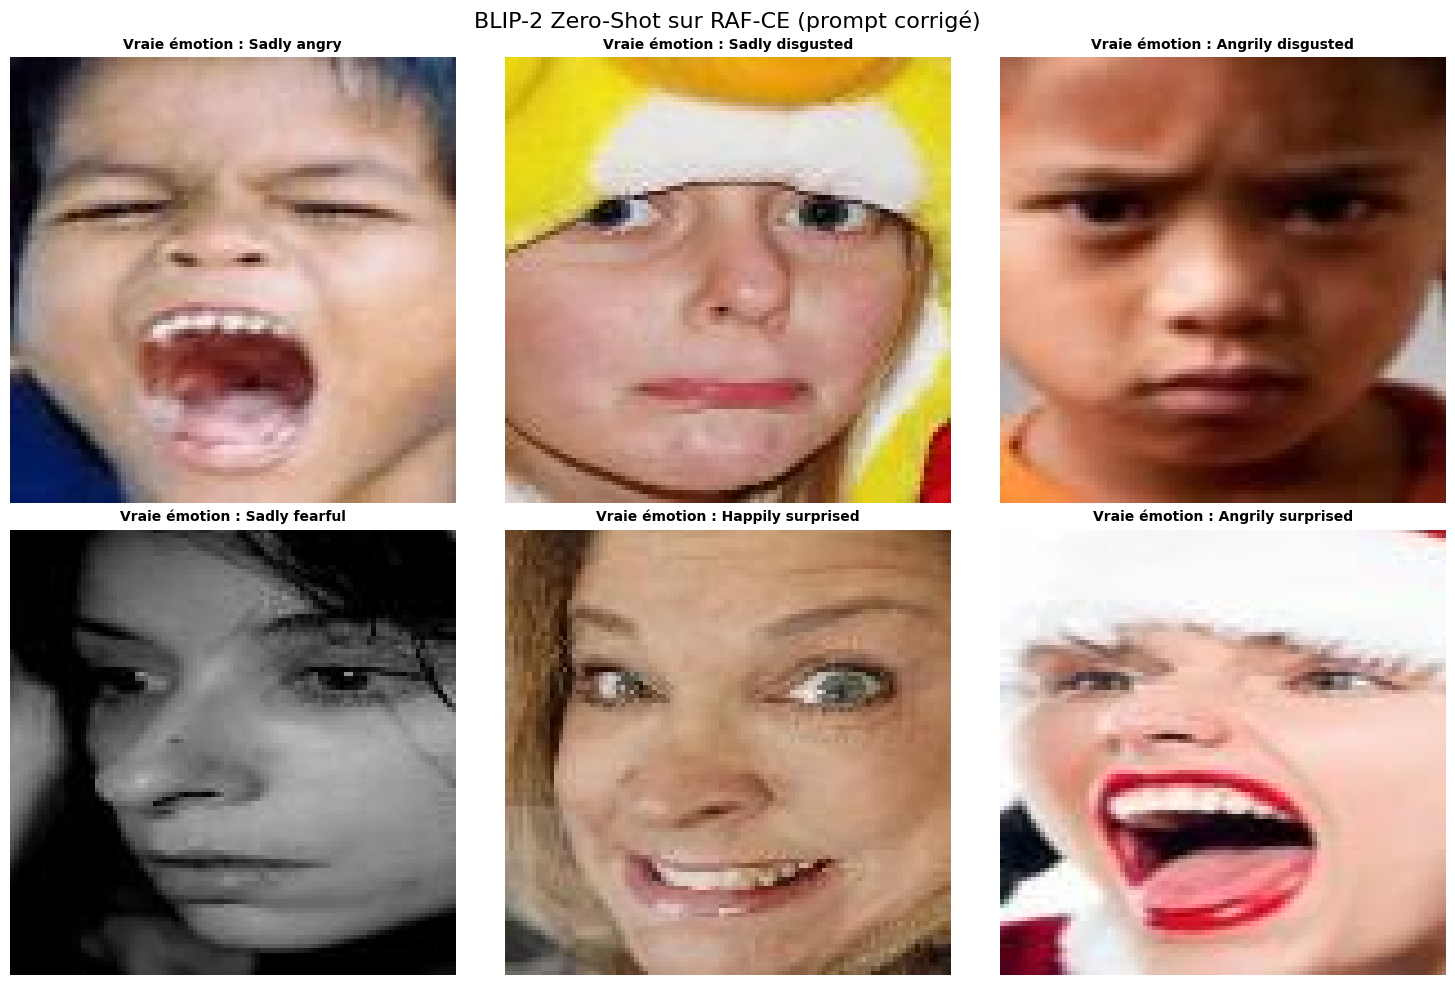

In [ ]:
# Cellule finale : Zero-shot BLIP-2
from datasets import load_from_disk
import random
import matplotlib.pyplot as plt

dataset = load_from_disk('/content/drive/MyDrive/RAF-CE/dataset_hf')
class_names = dataset['test'].features['label'].names

# Prompt SIMPLE et efficace pour BLIP-2
prompt = (
    "Question: Analyze the facial expression in the image.\n"
    "Step 1: Describe the visible facial cues (eyebrows, eyes, mouth, muscle tension).\n"
    "Step 2: Choose the most appropriate emotion from the following list:\n"
    "Angrily Surprised, Disgustedly Surprised, Happily Surprised, Sadly Surprised,\n"
    "Angrily Disgusted, Fearfully Disgusted, Sadly Disgusted,\n"
    "Happily Angry, Fearfully Angry, Sadly Angry,\n"
    "Fearfully Sad, Sadly Fearful, Happily Disgusted, Fearfully Surprised.\n"
    "Answer:"
)



# Test sur 6 exemples
examples = random.sample(list(dataset["test"]), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("BLIP-2 Zero-Shot sur RAF-CE (prompt corrigé)", fontsize=16)

for i, ex in enumerate(examples):
    image = ex["image"]
    true_label = class_names[ex["label"]]

    # Encodage
    inputs = processor(
        images=image,
        text=prompt,
        return_tensors="pt"
    ).to(model.device)

    # Génération
    with torch.no_grad():
         generated_ids = model.generate(
        **inputs,
        max_new_tokens=80,
        num_beams=5,
        do_sample=False,
        repetition_penalty=1.3,
        length_penalty=1.0,
    )


    generated_text = processor.decode(
        generated_ids[0],
        skip_special_tokens=True
    )

    # Affichage image
    ax = axes[i // 3, i % 3]
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(f"Vraie émotion : {true_label}", fontsize=10, fontweight="bold")

    # Affichage texte
    print(f"\n--- Exemple {i+1} ---")
    print(f"Vraie émotion : {true_label}")
    print(f"BLIP-2 répond : {generated_text}")
    print("-" * 60)

plt.tight_layout()
plt.show()


In [ ]:
from datasets import load_from_disk

dataset = load_from_disk('/content/drive/MyDrive/RAF-CE/dataset_hf')
class_names = dataset['train'].features['label'].names

def format_example(example):
    emotion = class_names[example["label"]]

    prompt = (
        "Question: Which ONE compound emotion best describes the facial expression?\n"
        "Answer:"
    )

    answer = emotion

    return {
        "prompt": prompt,
        "answer": answer,
        "image": example["image"]
    }

train_ds = dataset["train"].map(format_example, remove_columns=dataset["train"].column_names)
val_ds   = dataset["validation"].map(format_example, remove_columns=dataset["validation"].column_names)

print(train_ds[0])


{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=100x100 at 0x7821B5E12960>, 'prompt': 'Question: Which ONE compound emotion best describes the facial expression?\nAnswer:', 'answer': 'Sadly disgusted'}


In [ ]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 5,242,880 || all params: 3,750,004,736 || trainable%: 0.1398


In [ ]:
def blip2_collator(examples):
    images = [ex["images"][0] for ex in examples]

    texts = []
    for ex in examples:
        user_msg = ex["messages"][0]["content"]
        assistant_msg = ex["messages"][1]["content"]
        texts.append(f"Question: {user_msg}\nAnswer: {assistant_msg}")

    inputs = processor(
        images=images,
        text=texts,
        padding=True,
        return_tensors="pt"
    )


    inputs["labels"] = inputs["input_ids"].clone()

    return inputs


In [ ]:
from transformers import Trainer, TrainingArguments

def blip2_collator(examples):
    images = [ex["image"] for ex in examples]

    texts = []
    for ex in examples:
        user_msg = ex["prompt"]
        assistant_msg = ex["answer"]
        texts.append(f"{user_msg} {assistant_msg}")

    inputs = processor(
        images=images,
        text=texts,
        padding=True,
        return_tensors="pt"
    )

    inputs["labels"] = inputs["input_ids"].clone()

    return inputs

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/RAF-CE/blip2_lora",
    num_train_epochs=5,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none",
    optim="paged_adamw_8bit",
    gradient_checkpointing=True,
    remove_unused_columns=False,
    dataloader_pin_memory=False,
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=blip2_collator,
)

In [ ]:
batch = blip2_collator([train_ds[0], train_ds[1]])
print(batch.keys())


KeysView({'input_ids': tensor([[50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265,
         50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265,
         50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265,
         50265, 50265,     2, 45641,    35,  6834, 19551, 10624, 11926,   275,
          7448,     5, 11560,  8151,   116, 50118, 33683,    35, 18810, 32759],
        [50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265,
         50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265,
         50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265, 50265,
         50265, 50265,     2, 45641,    35,  6834, 19551, 10624, 11926,   275,
          7448,     5, 11560,  8151,   116, 50118, 33683,    35, 18810,  5800]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
   

In [ ]:
trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
1,0.335300,0.037642
2,0.237600,0.031097
3,0.240800,0.031872
4,0.208800,0.028109
5,0.218000,0.026452


/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


TrainOutput(global_step=850, training_loss=1.1817665086073035, metrics={'train_runtime': 3701.1669, 'train_samples_per_second': 3.66, 'train_steps_per_second': 0.23, 'total_flos': 4.423574951769932e+19, 'train_loss': 1.1817665086073035, 'epoch': 5.0})

In [ ]:
model.print_trainable_parameters()


trainable params: 5,242,880 || all params: 3,750,004,736 || trainable%: 0.1398



--- Exemple 1 ---
Vraie émotion : Sadly disgusted
Prédiction    : Sadly disgusted ✓
Réponse complète : What compound emotion is the person expressing? Answer: Sadly disgusted
--------------------------------------------------------------------------------

--- Exemple 2 ---
Vraie émotion : Fearfully surprised
Prédiction    : Sadly fearful ✗
Réponse complète : What compound emotion is the person expressing? Answer: Sadly fearful

--------------------------------------------------------------------------------

--- Exemple 3 ---
Vraie émotion : Sadly disgusted
Prédiction    : Angrily disgusted ✗
Réponse complète : What compound emotion is the person expressing? Answer: Angrily disgusted

--------------------------------------------------------------------------------

--- Exemple 4 ---
Vraie émotion : Happily surprised
Prédiction    : Happily surprised ✓
Réponse complète : What compound emotion is the person expressing? Answer: Happily surprised

----------------------------------------

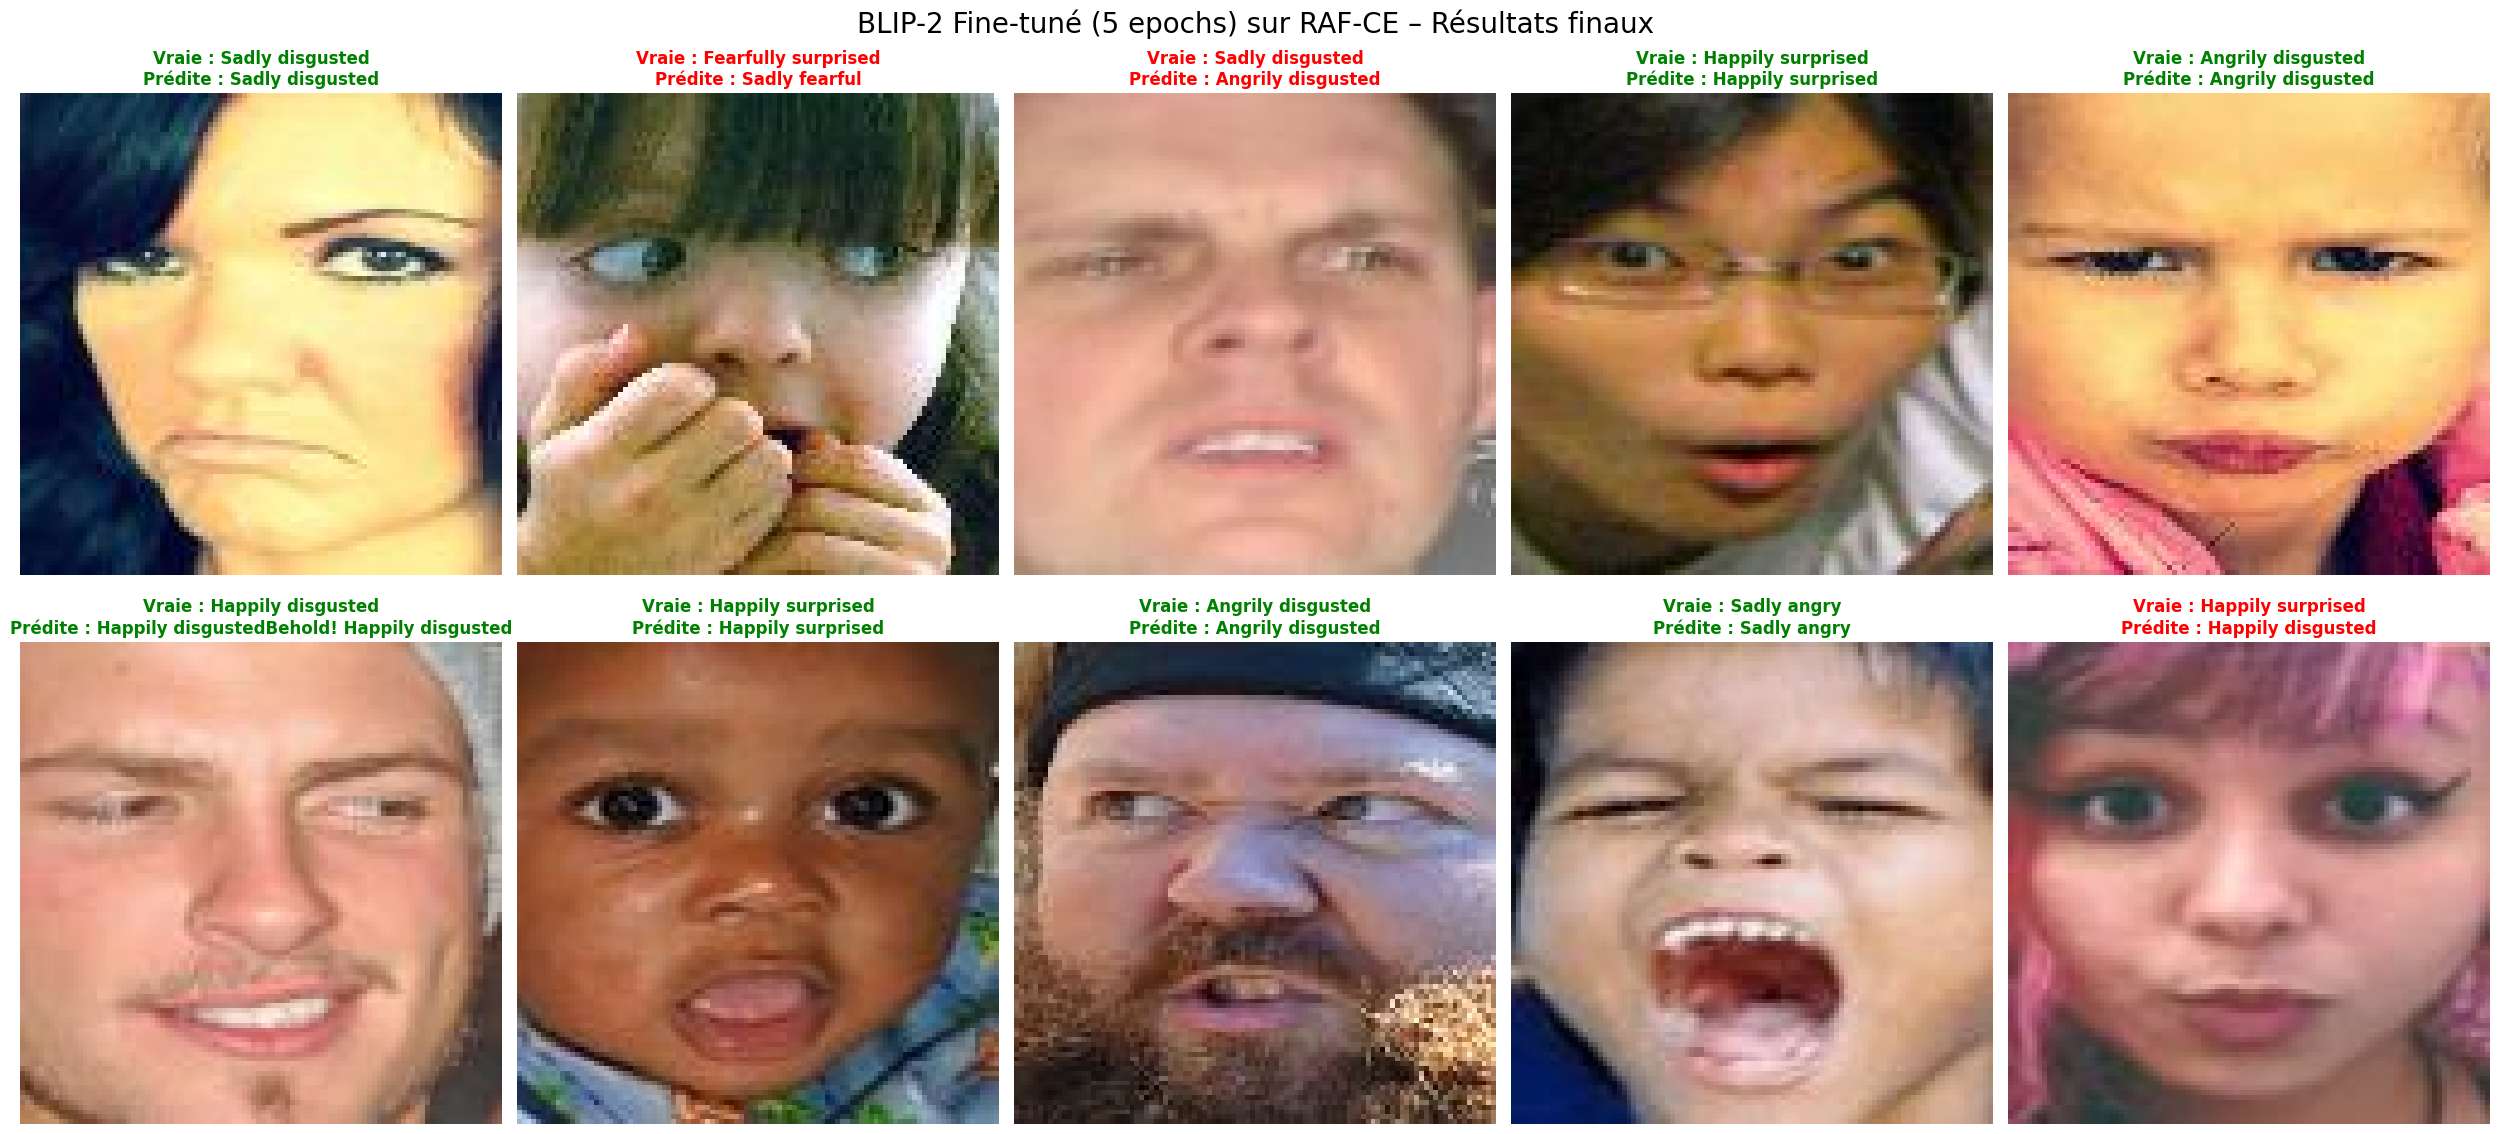

In [ ]:
# Test final du modèle fine-tuné (classification + explication)
from datasets import load_from_disk
import random
import matplotlib.pyplot as plt

test_dataset = load_from_disk('/content/drive/MyDrive/RAF-CE/dataset_hf')['test']
class_names = test_dataset.features['label'].names

# Prompt  pour déclencher la réponse apprise
prompt = "What compound emotion is the person expressing? Answer:"

# 10 exemples aléatoires pour bien voir la performance
examples = random.sample(list(test_dataset), 10)

fig, axes = plt.subplots(2, 5, figsize=(25, 12))
fig.suptitle("BLIP-2 Fine-tuné (5 epochs) sur RAF-CE – Résultats finaux", fontsize=20)

correct_count = 0

for i, ex in enumerate(examples):
    image = ex['image']
    true_emotion = class_names[ex['label']]

    inputs = processor(image, prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=50,
            num_beams=5,
            do_sample=False,
            repetition_penalty=1.2
        )

    response = processor.decode(generated_ids[0], skip_special_tokens=True)

    # Extraction de la prédiction
    if "Answer:" in response:
        predicted = response.split("Answer:")[1].strip().split('.')[0].strip()
    else:
        predicted = response.strip().split('.')[0].strip()

    # Compte les corrects
    is_correct = true_emotion.lower() in predicted.lower() or predicted.lower() in true_emotion.lower()
    if is_correct:
        correct_count += 1

    color = 'green' if is_correct else 'red'

    # Affichage image
    ax = axes[i//5, i%5]
    ax.imshow(image)
    ax.axis('off')
    ax.set_title(f"Vraie : {true_emotion}\nPrédite : {predicted}",
                 fontsize=12, fontweight='bold', color=color)

    print(f"\n--- Exemple {i+1} ---")
    print(f"Vraie émotion : {true_emotion}")
    print(f"Prédiction    : {predicted} {'✓' if is_correct else '✗'}")
    print(f"Réponse complète : {response}")
    print("-" * 80)

print(f"\nAccuracy sur ces 10 exemples : {correct_count}/10 ({correct_count*10}%)")

plt.tight_layout()
plt.show()



 # **XAI**

In [ ]:
# === CELLULE 1 : Installation propre et compatible  ===
!pip uninstall -y numpy pytensor jaxlib opencv-contrib-python tobler jax shap rasterio torchvision captum torchcam opencv-python opencv-python-headless -q

!pip install -q numpy==1.26.4
!pip install -q captum==0.7.0  # version stable qui accepte NumPy 1.26
!pip install -q opencv-python-headless==4.9.0.80  # version compatible NumPy 1.26
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

print("Installation terminée ! Versions :")
import numpy as np
import captum
import cv2
print("NumPy :", np.__version__)
print("Captum :", captum.__version__)
print("OpenCV :", cv2.__version__)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
orbax-checkpoint 0.11.31 requires jax>=0.6.0, which is not installed.
rasterstats 0.20.0 requires rasterio>=1.0, which is not installed.
pymc 5.27.0 requires pytensor<2.37,>=2.36.0, which is not installed.
albucore 0.0.24 requires opencv-python-headless>=4.9.0.80, which is not installed.
chex 0.1.90 requires jax>=0.4.27, which is not installed.
chex 0.1.90 requires jaxlib>=0.4.27, which is not installed.
albumentations 2.0.8 requires opencv-python-headless>=4.9.0.80, which is not installed.
flax 0.10.7 requires jax>=0.6.0, which is not installed.
fastai 2.8.6 requires torchvision>=0.11, which is not installed.
optax 0.2.6 requires jax>=0.5.3, which is not installed.
optax 0.2.6 requires jaxlib>=0.5.3, which is not installed.
dopamine-rl 4.1.2 requires jax>=0.1.72, which is not installed.
dopamine-rl 4.1.2 requires

In [ ]:
# === INSTALLATION XAI  ===
!pip install -q captum==0.7.0  # version stable avec ViT
!pip install -q opencv-python-headless==4.9.0.80

print("Captum et OpenCV installés")
import numpy as np
print("NumPy version :", np.__version__)

Captum et OpenCV installés
NumPy version : 2.0.2



Exemple 747


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using non-full backward hooks on a Module that does not take as input a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_input. Please use register_full_backward_hook to get the documented behavior.
  hook_result = hook(self, args, result)  # type: ignore[possibly-undefined]


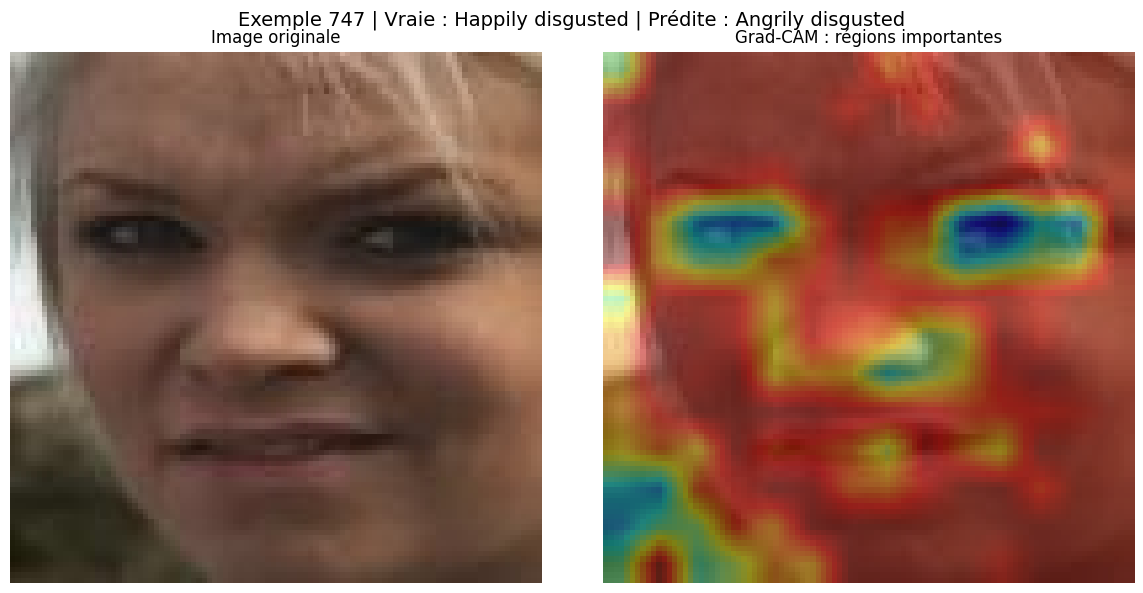

**Action Units annotées** : 4+12+25
**Zones faciales correspondantes** : 4+12+25 (non mappé)

Interprétation XAI :
- Grad-CAM met l'accent sur les zones activées pour la prédiction
- Vérifie si ces zones correspondent aux AUs annotés
- Exemple : yeux grands ouverts → AU5 (surprise/fear) → heatmap forte sur yeux

Exemple 470


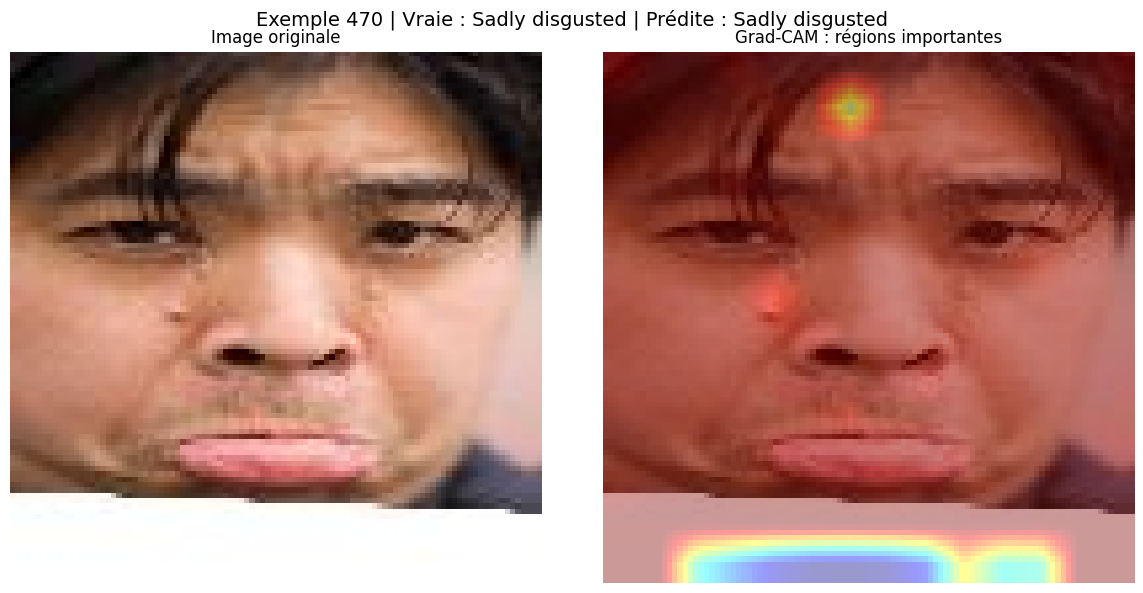

**Action Units annotées** : 1+4+15+17+B22+T24
**Zones faciales correspondantes** : 1+4+15+17+B22+T24 (non mappé)

Interprétation XAI :
- Grad-CAM met l'accent sur les zones activées pour la prédiction
- Vérifie si ces zones correspondent aux AUs annotés
- Exemple : yeux grands ouverts → AU5 (surprise/fear) → heatmap forte sur yeux

Exemple 549


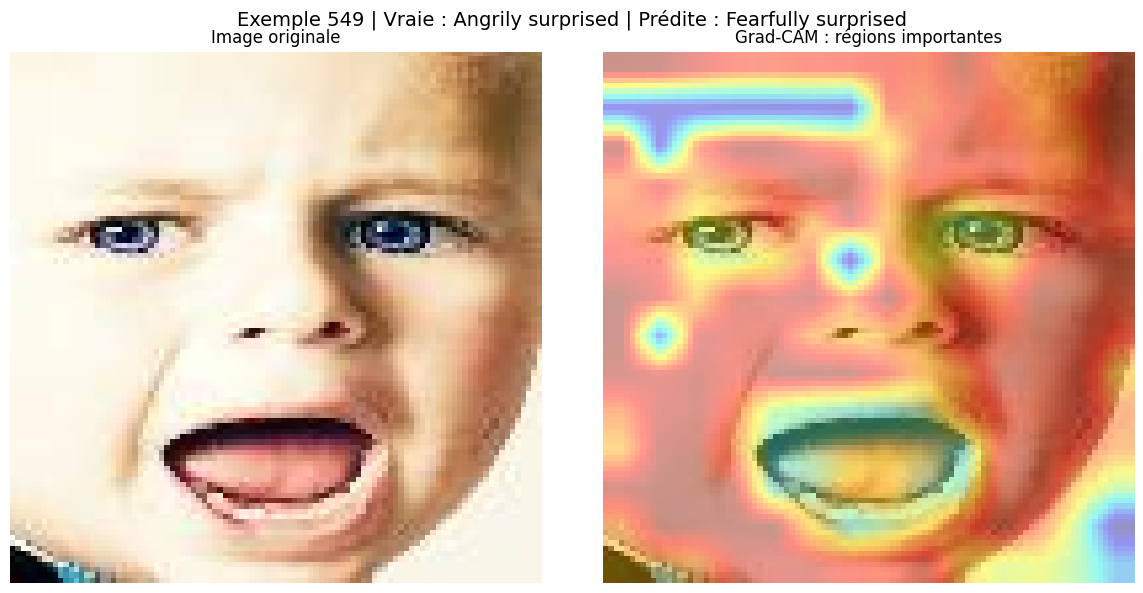

**Action Units annotées** : 4+12+16+25+27
**Zones faciales correspondantes** : 4+12+16+25+27 (non mappé)

Interprétation XAI :
- Grad-CAM met l'accent sur les zones activées pour la prédiction
- Vérifie si ces zones correspondent aux AUs annotés
- Exemple : yeux grands ouverts → AU5 (surprise/fear) → heatmap forte sur yeux

Exemple 127


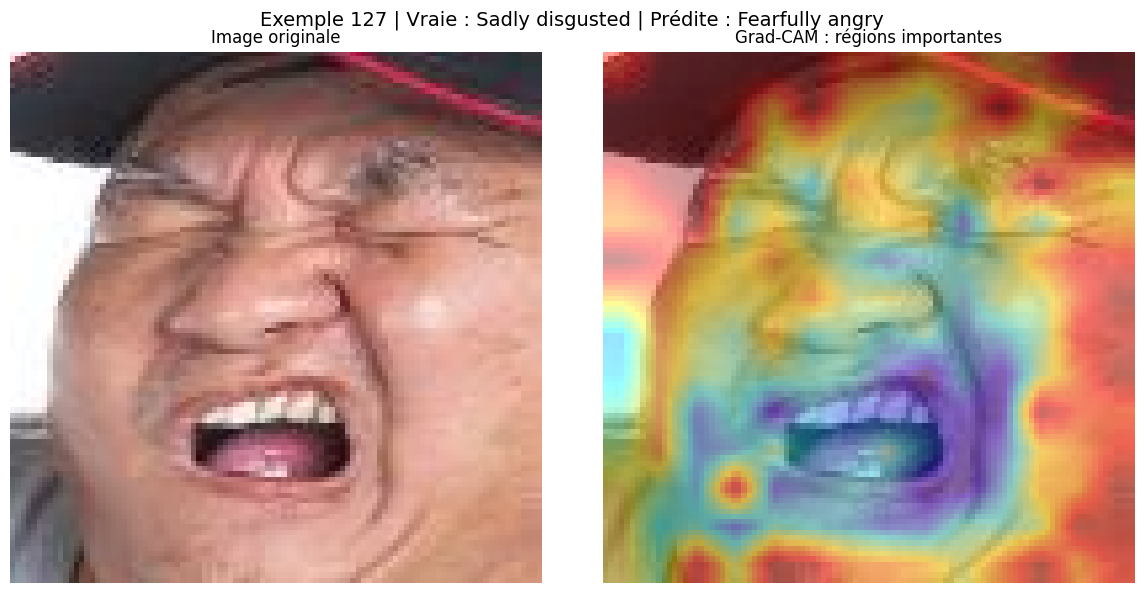

**Action Units annotées** : 4+6+9+10+25+26+43
**Zones faciales correspondantes** : 4+6+9+10+25+26+43 (non mappé)

Interprétation XAI :
- Grad-CAM met l'accent sur les zones activées pour la prédiction
- Vérifie si ces zones correspondent aux AUs annotés
- Exemple : yeux grands ouverts → AU5 (surprise/fear) → heatmap forte sur yeux

Exemple 387


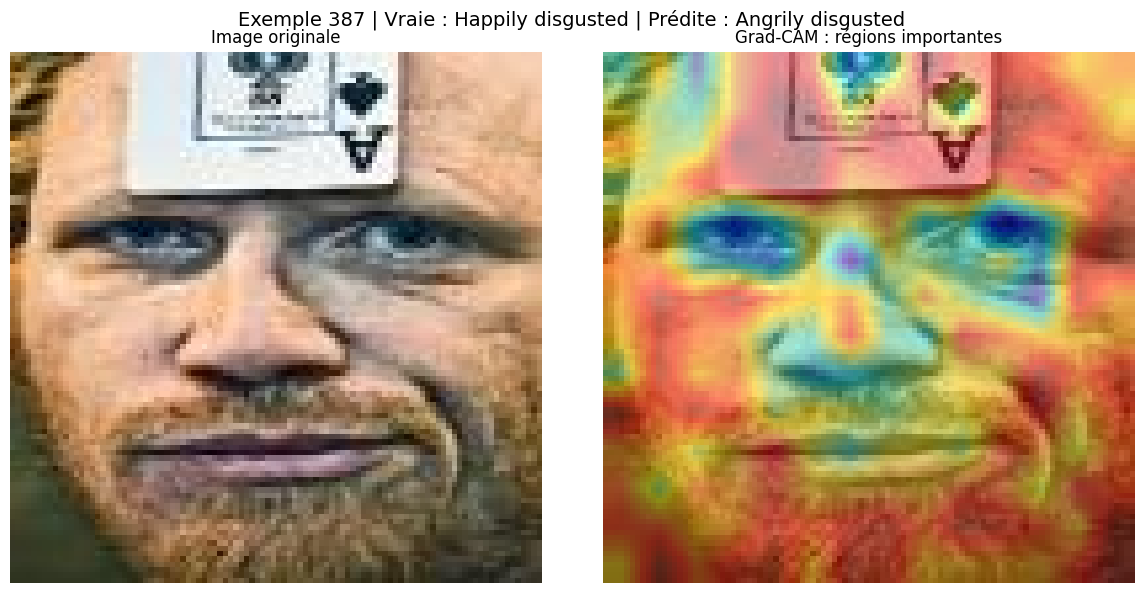

**Action Units annotées** : L12+L14
**Zones faciales correspondantes** : L12+L14 (non mappé)

Interprétation XAI :
- Grad-CAM met l'accent sur les zones activées pour la prédiction
- Vérifie si ces zones correspondent aux AUs annotés
- Exemple : yeux grands ouverts → AU5 (surprise/fear) → heatmap forte sur yeux


In [ ]:
# === SECTION XAI : Grad-CAM manuel simple pour ViT + Interprétation Action Units ===
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2
from datasets import load_from_disk
from transformers import ViTImageProcessor, ViTForImageClassification
import random

# Recharge dataset
dataset = load_from_disk('/content/drive/MyDrive/RAF-CE/dataset_hf')
class_names = dataset['test'].features['label'].names

# Recharge ViT
vit_model_path = '/content/drive/MyDrive/RAF-CE/vit_baseline_final'
vit_processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')
vit_model = ViTForImageClassification.from_pretrained(vit_model_path)
vit_model.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
vit_model.to(device)

# Mapping AUs → zones faciales (FACS simplifié)
au_to_zone = {
    'AU1': 'Inner brow raiser (surprise/sad)',
    'AU2': 'Outer brow raiser (surprise)',
    'AU4': 'Brow lowerer (anger/sad/disgust)',
    'AU5': 'Upper lid raiser (surprise/fear)',
    'AU6': 'Cheek raiser (happy)',
    'AU7': 'Lid tightener (anger/disgust)',
    'AU9': 'Nose wrinkler (disgust)',
    'AU12': 'Lip corner puller (happy)',
    'AU15': 'Lip corner depressor (sad)',
    'AU20': 'Lip stretcher (fear)',
    'AU25': 'Lips part (surprise/fear)'
}

def map_aus_to_zones(au_string):
    if not au_string or au_string in ['No AU', 'null']:
        return "Aucune Action Unit annotée"
    aus = str(au_string).split()
    zones = [au_to_zone.get(au.strip(), f"{au} (non mappé)") for au in aus]
    return ", ".join(zones) if zones else "Aucune zone reconnue"

# Grad-CAM manuel simple (sans Captum, plus stable avec ViT)
def compute_gradcam_manual(model, input_tensor, target_class):
    model.zero_grad()
    model.eval()

    activations = []
    gradients = []

    # Hook forward
    def forward_hook(module, input, output):
        activations.append(output)

    # Hook backward
    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    target_layer = model.vit.encoder.layer[-1]

    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_backward_hook(backward_hook)

    outputs = model(input_tensor)
    logits = outputs.logits
    score = logits[0, target_class]

    score.backward()

    h1.remove()
    h2.remove()

    activations = activations[0]    # (1, seq_len, hidden)
    gradients = gradients[0]        # (1, seq_len, hidden)

    weights = gradients.mean(dim=1) # (1, hidden)

    cam = torch.matmul(activations, weights.unsqueeze(-1)).squeeze(-1)
    cam = cam[:, 1:]                # remove CLS token

    cam = cam.reshape(14, 14)
    cam = cam.detach().cpu().numpy()

    cam = np.maximum(cam, 0)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    return cam



# Superposition heatmap
def overlay_heatmap(image, heatmap):
    img = np.array(image)
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img, 0.6, heatmap_colored, 0.4, 0)
    return Image.fromarray(superimposed)

# Fonction principale XAI
def xai_visualization(example_idx):
    example = dataset['test'][example_idx]
    image = example['image']
    true_label = class_names[example['label']]
    au_zones = map_aus_to_zones(example['au_string'])

    # Prédiction ViT
    inputs = vit_processor(image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = vit_model(**inputs)
    pred_label = outputs.logits.argmax(-1).item()
    predicted = class_names[pred_label]

    # Grad-CAM manuel
    target_class = pred_label
    gradcam = compute_gradcam_manual(vit_model, inputs['pixel_values'], target_class)

    # Superposition
    heatmap_overlay = overlay_heatmap(image, gradcam)

    # Affichage
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f"Exemple {example_idx} | Vraie : {true_label} | Prédite : {predicted}", fontsize=14)

    ax1.imshow(image)
    ax1.set_title("Image originale")
    ax1.axis('off')

    ax2.imshow(heatmap_overlay)
    ax2.set_title("Grad-CAM : régions importantes")
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"**Action Units annotées** : {example['au_string']}")
    print(f"**Zones faciales correspondantes** : {au_zones}")
    print(f"\nInterprétation XAI :")
    print("- Grad-CAM met l'accent sur les zones activées pour la prédiction")
    print("- Vérifie si ces zones correspondent aux AUs annotés")
    print("- Exemple : yeux grands ouverts → AU5 (surprise/fear) → heatmap forte sur yeux")

# Test sur 5 exemples aléatoires
random_indices = random.sample(range(len(dataset['test'])), 5)
for idx in random_indices:
    print(f"\n{'='*60}\nExemple {idx}\n{'='*60}")
    xai_visualization(idx)